In [322]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [323]:
data= load_breast_cancer()

In [324]:
df= pd.DataFrame(data.data, columns= data.feature_names)
df['Target']= data.target

In [325]:
df.sample(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
80,11.45,20.97,73.81,401.5,0.11020,0.09362,0.04591,0.02233,0.1842,0.07005,...,32.16,84.53,525.1,0.1557,0.1676,0.1755,0.06127,0.2762,0.08851,1
324,12.20,15.21,78.01,457.9,0.08673,0.06545,0.01994,0.01692,0.1638,0.06129,...,21.38,91.11,583.1,0.1256,0.1928,0.1167,0.05556,0.2661,0.07961,1
109,11.34,21.26,72.48,396.5,0.08759,0.06575,0.05133,0.01899,0.1487,0.06529,...,29.15,83.99,518.1,0.1699,0.2196,0.3120,0.08278,0.2829,0.08832,1
87,19.02,24.59,122.00,1076.0,0.09029,0.12060,0.14680,0.08271,0.1953,0.05629,...,30.41,152.90,1623.0,0.1249,0.3206,0.5755,0.19560,0.3956,0.09288,0
339,23.51,24.27,155.10,1747.0,0.10690,0.12830,0.23080,0.14100,0.1797,0.05506,...,30.73,202.40,2906.0,0.1515,0.2678,0.4819,0.20890,0.2593,0.07738,0


In [326]:
X= df.iloc[:, :-1]
y= df.iloc[:, -1]

In [327]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state= 42)

#### Single Decision Tree

In [328]:
model1= DecisionTreeClassifier(random_state= 42)

In [329]:
cv_model1= cross_val_score(model1, X_train, y_train, cv=5) 
print(np.round(cv_model1, 2))
print("Avg CV Score:", np.round(np.mean(cv_model1), 2))

[0.92 0.89 0.93 0.9  0.93]
Avg CV Score: 0.92


In [330]:
model1.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [331]:
y_pred1= model1.predict(X_test)

In [332]:
result= pd.DataFrame({"Actual": y_test, "Predicted": y_pred1})
print(result)

     Actual  Predicted
204       1          1
70        0          0
131       0          0
431       1          1
540       1          1
..      ...        ...
486       1          1
75        0          0
249       1          1
238       1          1
265       0          0

[114 rows x 2 columns]


In [333]:
print("Accuracy Score:", np.round(accuracy_score(y_test, y_pred1), 2))

Accuracy Score: 0.95


In [334]:
print("Classification Report:", classification_report(y_test, y_pred1))

Classification Report:               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



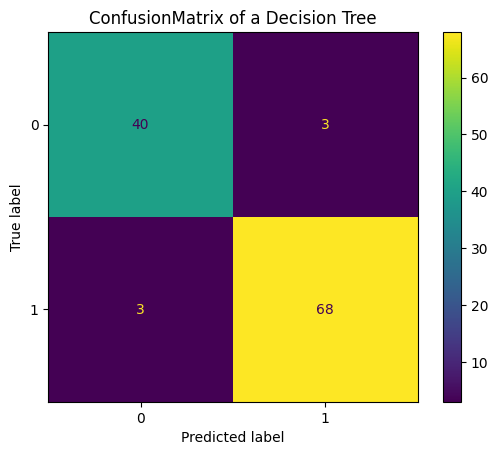

In [335]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred1)
plt.title("ConfusionMatrix of a Decision Tree")
plt.show()

#### Bagging Ensemble

In [336]:
model2= BaggingClassifier(DecisionTreeClassifier(random_state= 42), n_estimators= 50, max_samples= 0.8, bootstrap= True, random_state= 42)

# 50 decision trees (n_estimators= 50)
# randomly selecting data with replacement (bootstrap=True)
# sees a random 80% of the data (max_samples=0.8)

In [337]:
cv_model2= cross_val_score(model2, X_train, y_train, cv=5) 
print(np.round(cv_model2, 2))
print("Avg CV Score:", np.round(np.mean(cv_model2), 2))

[0.95 0.92 0.98 0.96 0.93]
Avg CV Score: 0.95


In [338]:
model2.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",50
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [339]:
y_pred2= model2.predict(X_test)

In [340]:
result= pd.DataFrame({"Actual": y_test, "Predicted": y_pred2})
print(result)

     Actual  Predicted
204       1          1
70        0          0
131       0          0
431       1          1
540       1          1
..      ...        ...
486       1          1
75        0          0
249       1          1
238       1          1
265       0          0

[114 rows x 2 columns]


In [341]:
print("Accuracy Score:", np.round(accuracy_score(y_test, y_pred2), 2))

Accuracy Score: 0.96


In [342]:
print("Classification Report:", classification_report(y_test, y_pred2))

Classification Report:               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



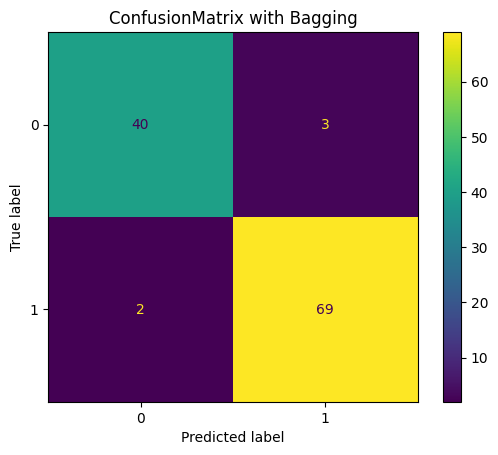

In [343]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred2)
plt.title("ConfusionMatrix with Bagging")
plt.show()

#### Bagging using different Algorithms

In [344]:
estimators= {
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "SVM": make_pipeline(StandardScaler(), SVC())
}


Cross Validation Score Decision Tree:  [0.95 0.92 0.98 0.96 0.93]
Average Cross Validation Score Decision Tree: 0.95

Classification Report Decision Tree:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



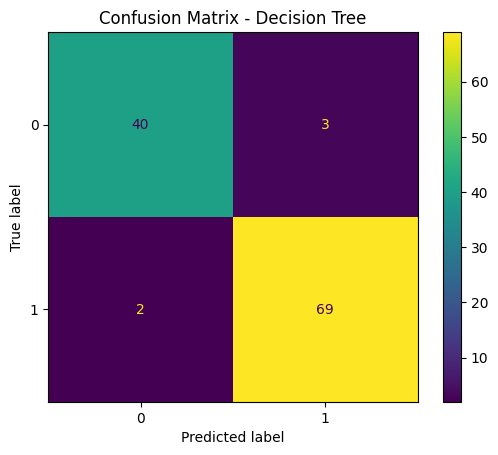


Cross Validation Score KNN:  [0.97 0.95 1.   0.97 0.92]
Average Cross Validation Score KNN: 0.96

Classification Report KNN:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



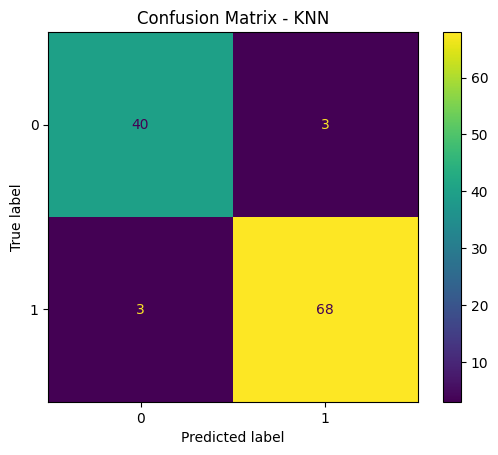


Cross Validation Score SVM:  [0.97 0.97 0.99 0.99 0.93]
Average Cross Validation Score SVM: 0.97

Classification Report SVM:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



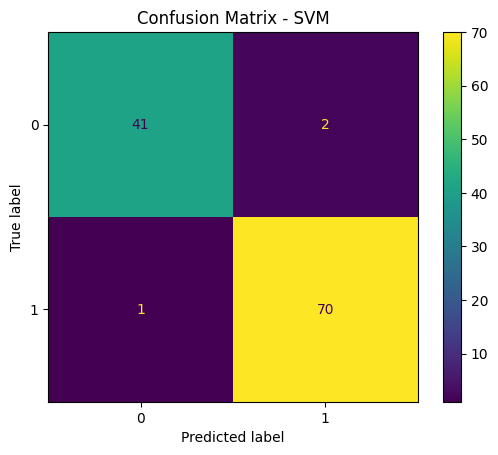

In [345]:
for name, estimator in estimators.items():
    model3= BaggingClassifier(estimator= estimator, random_state=42, max_samples= 0.8, bootstrap= True, n_estimators= 50)

    model3_cv= cross_val_score(model3, X_train, y_train, cv=5)
    print(f"\nCross Validation Score {name}:  {np.round(model3_cv, 2)}")
    print(f"Average Cross Validation Score {name}: {np.round(np.mean(model3_cv), 2)}")

    model3.fit(X_train, y_train)
    y_pred3= model3.predict(X_test)

    print(f"\nClassification Report {name}:\n", classification_report(y_test, y_pred3))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred3)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

##### Bagging treats each base estimator independently. Each Bagging model gives its own final prediction — the 150 models do NOT all vote together. You get 3 separate predictions, not one combined vote of 150.If you want all 150 to vote together as one model, that's where Voting Classifier comes in